<a href="https://colab.research.google.com/github/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/blob/main/CERVICAL_CANCER_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lifestyle-Based Cervical Cancer Risk Prediction and Population Burden Analysis in West Africa**



## **1. Cervical Cancer Risk Prediction**
The aim of this project is to develop and evaluate machine learning models for cervical cancer risk prediction using individual-level data. The study uses demographic, behavioural, and medical features to identify patterns associated with biopsy-confirmed outcomes.

Multiple models are compared, and pre-processing techniques such as handling missing values, feature scaling, and class balancing are applied. Performance is evaluated using metrics including accuracy, precision, recall, and F1-score, with emphasis on detecting positive cases.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score

In [5]:
# Load the dataset from the specified CSV file
df = 'https://raw.githubusercontent.com/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/refs/heads/main/data/risk_factors_cervical_cancer.csv'
data = pd.read_csv(df)

# Convert all columns to numeric types, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')


In [6]:
# Display columns with missing values and their percentages
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("Columns with missing values and their percentages (before imputation):\n", missing_info)

# Drop columns that have more than 90% missing values (NaNs)
data = data.loc[:, data.isnull().mean() < 0.9]

# Impute missing values (NaNs) using the median strategy AFTER train-test split
imputer = SimpleImputer(strategy='median')
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

data.head()

Columns with missing values and their percentages (before imputation):
                                     Missing Count  Missing Percentage
STDs: Time since first diagnosis              787           91.724942
STDs: Time since last diagnosis               787           91.724942
IUD (years)                                   117           13.636364
IUD                                           117           13.636364
Hormonal Contraceptives                       108           12.587413
Hormonal Contraceptives (years)               108           12.587413
STDs (number)                                 105           12.237762
STDs                                          105           12.237762
STDs:vulvo-perineal condylomatosis            105           12.237762
STDs:vaginal condylomatosis                   105           12.237762
STDs:pelvic inflammatory disease              105           12.237762
STDs:syphilis                                 105           12.237762
STDs:genital herpe

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18.0,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,15.0,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34.0,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,52.0,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,46.0,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Assign the 'Biopsy' column as the target variable (y)
y = data['Biopsy']

# Assign all other columns as feature variables (X) by dropping 'Biopsy', 'Hinselmann', 'Schiller', and 'Citology' from the DataFrame
X = data.drop(columns=['Biopsy', 'Hinselmann', 'Schiller', 'Citology'])

print(X.shape)
print(y.shape)

(858, 30)
(858,)


## **1.1 Exploratory Data Analysis**
Exploratory Data Analysis (EDA) was conducted to understand the dataset’s structure, detect missing values, and examine feature distributions.
The target variable (Biopsy) showed significant class imbalance, while correlation analysis revealed stronger relationships with clinical variables than lifestyle factors.
These insights guided preprocessing steps, including feature selection and data balancing.

### 1.1.1 Biopsy Distribution

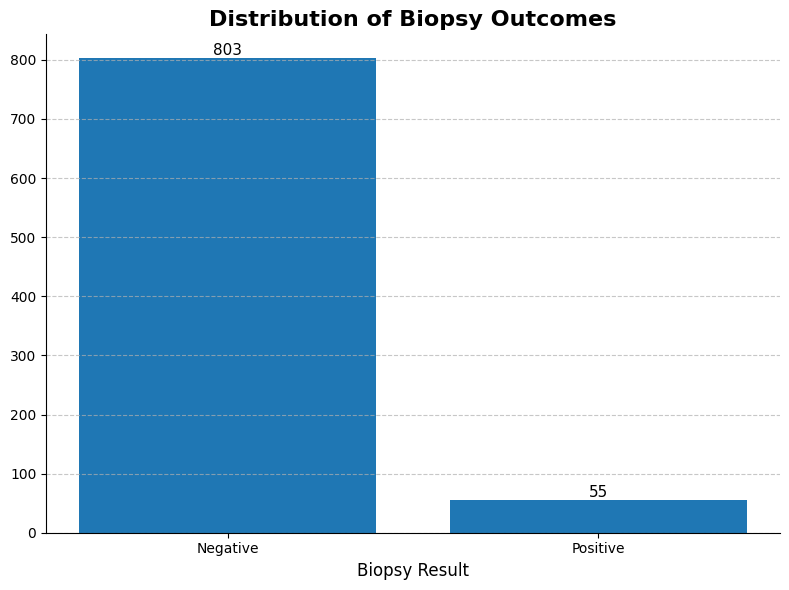

In [8]:
def plot_biopsy_distribution(y, filename='biopsy_class_distribution.png'):
    plt.figure(figsize=(8, 6))

    # Get unique classes and their counts from the target variable 'y'
    classes, counts = np.unique(y, return_counts=True)
    # Create a bar plot using the classes and their counts
    bars = plt.bar(classes, counts)


    plt.title("Distribution of Biopsy Outcomes", fontsize=16, fontweight='bold')
    plt.xlabel("Biopsy Result", fontsize=12)

    if set(classes) == {0, 1}:
        plt.xticks(classes, ["Negative", "Positive"])

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{int(height)}',
                 ha='center', va='bottom', fontsize=11)

    # Hide the top and right spines of the plot for a cleaner look
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_biopsy_distribution(y)

The distribution of the target variable (Biopsy) highlights a significant class imbalance, with 803 negative cases and only 55 positive cases. This imbalance suggests that the dataset is dominated by non-cancer instances, which could lead to biased model predictions if not properly addressed.

### 1.1.2 Lifestyle Variables Distribution

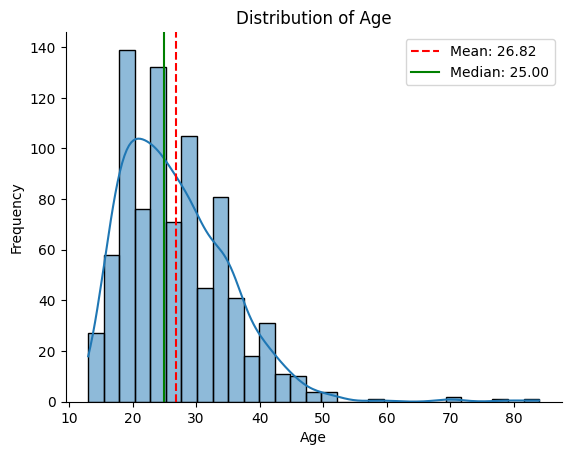

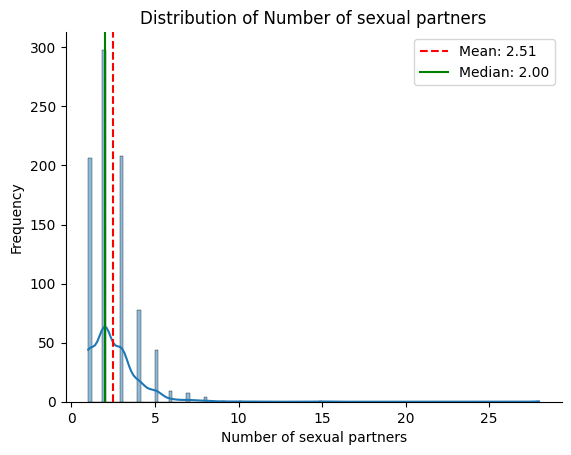

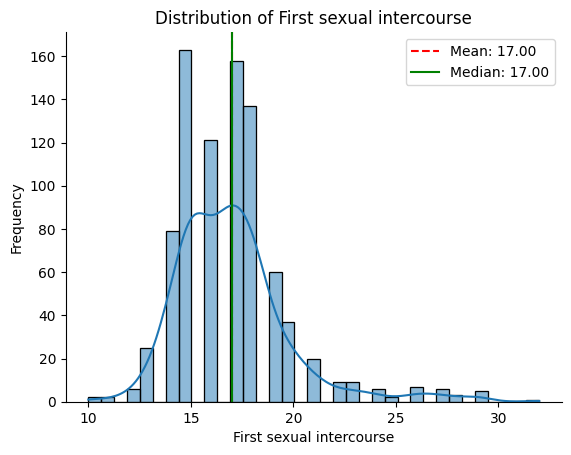

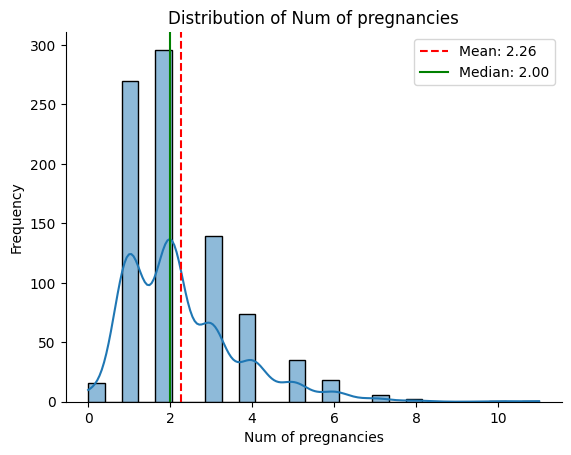

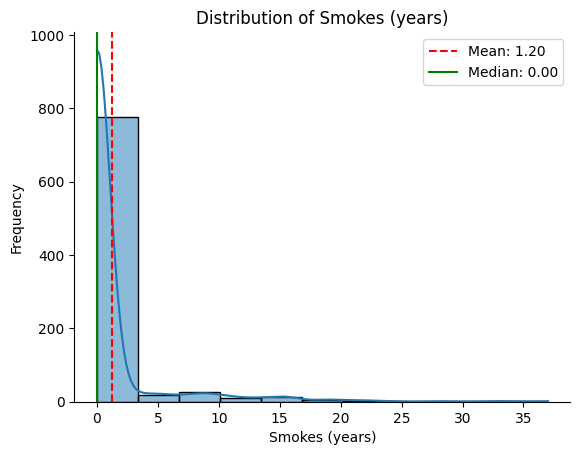

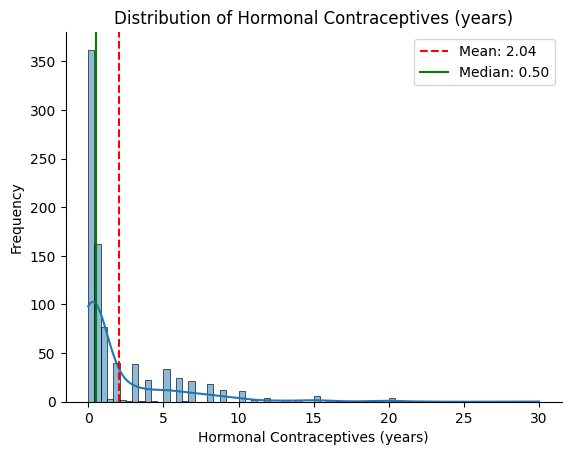

In [9]:
def plot_lifestyle_distribution(data_df, col):
    plt.figure()
    sns.histplot(data=data_df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Calculate mean and median
    mean_val = data_df[col].mean()
    median_val = data_df[col].median()

    # Add vertical lines for mean and median
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    plt.legend()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.savefig(f'distribution_of_{col.lower().replace(" ", "_")}.png')
    plt.show()

lifestyle_variables = ['Age', 'Number of sexual partners', 'First sexual intercourse',
                       'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)']

# Loop through the lifestyle variables and call the function for each
for col in lifestyle_variables:
    plot_lifestyle_distribution(X, col)

The lifestyle visualizations reveal that most of these risk factors, such as 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', and 'Hormonal Contraceptives (years)', exhibit right-skewed distributions. This indicates that a larger portion of the population in the dataset tends to have lower values for these variables. 'Age' shows a more balanced distribution but still leans towards younger individuals. The mean and median lines on each plot help in understanding the central tendency and the skewness of each variable's distribution.

### 1.1.3 Correlation Matrix
The correlation heatmap primarily focuses on variables that show a positive relationship with the biopsy outcome. Strong positive correlations are observed among screening and clinical variables, indicating their close association with confirmed cervical cancer cases. In contrast, demographic and lifestyle factors exhibit weaker correlations.
These findings help identify the most relevant features for prediction and inform feature selection for the machine learning models.

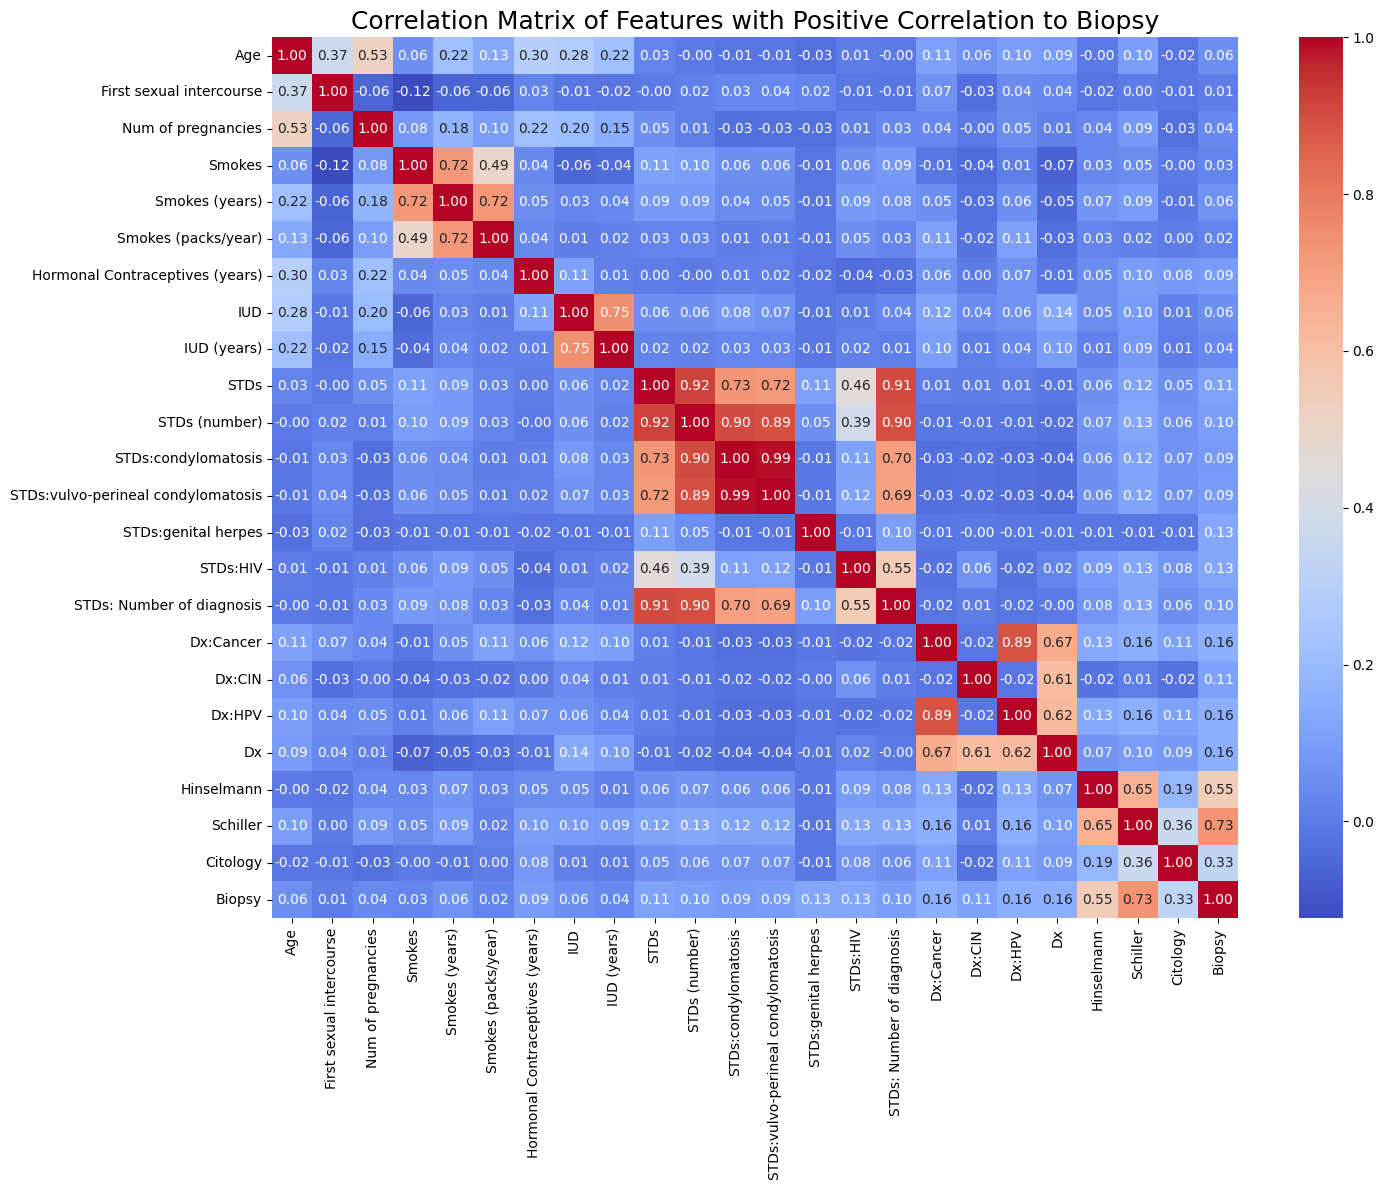

In [10]:
def plot_positive_correlation_matrix(data, filename='positive_correlation_matrix.png'):
    biopsy_corr = data.corr()['Biopsy']
    positive_corr_features = biopsy_corr[biopsy_corr > 0].index.tolist()

    # Ensure 'Biopsy' itself is included for the heatmap
    if 'Biopsy' not in positive_corr_features:
        positive_corr_features.append('Biopsy')

    filtered_data = data[positive_corr_features]

    plt.figure(figsize=(15, 12))
    sns.heatmap(filtered_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Features with Positive Correlation to Biopsy', fontsize=18)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_positive_correlation_matrix(data)

## **1.2 Train/Test Split**

The dataset was split into training (80%) and testing (20%) sets to evaluate model performance on unseen data. Stratified sampling was used to maintain the class distribution of the target variable (Biopsy), and a fixed random state ensured reproducibility.
Feature scaling was applied using StandardScaler, fitted on the training data and applied to the test data to prevent data leakage.

In [11]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=50
)

# Impute missing values (NaNs) using the median strategy AFTER train-test split
# imputer = SimpleImputer(strategy='median')
# X_train = imputer.fit_transform(X_train)
# X_test = imputer.transform(X_test)

# StandardScaler:
# Standardizes features by removing the mean and scaling to unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print the shapes of the resulting datasets to verify the split
print(X_test.shape)
print(y_test.shape)
print(X_train.shape)
print(y_train.size)


(172, 30)
(172,)
(686, 30)
686


## **1.3 LOGISTIC REGRESSION**
Logistic Regression was used as a baseline model for predicting biopsy outcomes. It is suitable for binary classification and provides good interpretability of feature effects.
The model was trained on scaled data and evaluated using accuracy, precision, recall, and F1-score, with emphasis on recall for detecting positive cases.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


log_model = LogisticRegression(
    max_iter=1000, random_state=50
    )

# Train the logistic regression model on the scaled training data
log_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_log = log_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression (Standard)")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

Logistic Regression (Standard)
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96       161
         1.0       0.33      0.09      0.14        11

    accuracy                           0.93       172
   macro avg       0.64      0.54      0.55       172
weighted avg       0.90      0.93      0.91       172

ROC-AUC: 0.5372670807453417


Random Oversampling was applied to the logistic model to address class imbalance by increasing minority class samples.



In [13]:
!pip install imbalanced-learn
import imblearn
from imblearn.over_sampling import RandomOverSampler
oversample = RandomOverSampler(sampling_strategy='minority')
X_over, y_over = oversample.fit_resample(X_train_scaled, y_train)

In [14]:
# Create a new Logistic Regression model and train it on the oversampled data.
log_oversampled = LogisticRegression(max_iter=1000, random_state=50)
log_oversampled.fit(X_over, y_over)

y_pred_log_over = log_oversampled.predict(X_test_scaled)
y_proba_log_over = log_oversampled.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression with oversampling")
print(classification_report(y_test,y_pred_log_over))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log_over))

Logistic Regression with oversampling
              precision    recall  f1-score   support

         0.0       0.94      0.83      0.88       161
         1.0       0.07      0.18      0.10        11

    accuracy                           0.79       172
   macro avg       0.50      0.51      0.49       172
weighted avg       0.88      0.79      0.83       172

ROC-AUC: 0.4712027103331451


## **1.4 XGBoost Model**
XGBoost was used as an advanced ensemble model based on gradient boosting, capable of capturing complex relationships in the data. It includes regularisation to reduce overfitting and performs well on structured datasets.
Hyperparameter tuning was applied to optimise performance, and the model was evaluated using accuracy, precision, recall, and F1-score, with emphasis on detecting positive cases.

In [15]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


# Initialize the XGBoost classifier with a random state for reproducibility.
# Using some reasonable default parameters. Removed use_label_encoder as it's deprecated.
xgb_model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=None,
    max_depth=None,
    subsample=0.8,
    random_state=50,
    eval_metric='logloss'
)

# Train the XGBoost model on the scaled training data
xgb_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("XGBoost (Standard)")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

XGBoost (Standard)
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.96       161
         1.0       0.00      0.00      0.00        11

    accuracy                           0.92       172
   macro avg       0.47      0.49      0.48       172
weighted avg       0.88      0.92      0.90       172

ROC-AUC: 0.6338226990400903


In [16]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Initialize an XGBoost classifier with specified parameters. 'objective' is set for binary classification.
# Set use_label_encoder to False to avoid the warning, and eval_metric for binary classification.
xgb_tuned_model = XGBClassifier(objective='binary:logistic', random_state=50, eval_metric='logloss')

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_tuned_model,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearchCV to the oversampled training data (X_over, y_over).
grid_search.fit(X_over, y_over)

# Get the best estimator
best_xgb_model = grid_search.best_estimator_

print("Best hyperparameters found:", grid_search.best_params_)

# Make predictions on the scaled test data using the best model
y_pred_xgb_over = best_xgb_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_xgb_over = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model's performance.
print("XGBoost with oversampling and hyperparameter tuning")
print(classification_report(y_test, y_pred_xgb_over))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_over))


Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best hyperparameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
XGBoost with oversampling and hyperparameter tuning
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.93       161
         1.0       0.14      0.18      0.16        11

    accuracy                           0.88       172
   macro avg       0.54      0.55      0.55       172
weighted avg       0.89      0.88      0.88       172

ROC-AUC: 0.6614906832298137


# **1.5 RANDOM FOREST**
Random Forest was used as an ensemble model that combines multiple decision trees to improve accuracy and reduce overfitting. It can capture non-linear relationships and provides feature importance insights.
The model was evaluated using accuracy, precision, recall, and F1-score, with emphasis on detecting positive cases.

In [17]:
# Define the Random Forest classifier model with a fixed random state for reproducibility.
rf = RandomForestClassifier(
    n_estimators=100,  # Increased from 10 to 100 for better performance
    max_depth=None,
    random_state=50
)

# Fit the model to the scaled training data.
rf.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data.
y_predrf = rf.predict(X_test_scaled)

# Predict probabilities for the positive class (class 1) on the scaled test data.
y_proba_rf = rf.predict_proba(X_test_scaled)[:,1]

# Evaluate the model's performance without oversampling.
print("Random Forest (standard, no oversampling)")
print(classification_report(y_test, y_predrf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest (standard, no oversampling)
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97       161
         1.0       1.00      0.09      0.17        11

    accuracy                           0.94       172
   macro avg       0.97      0.55      0.57       172
weighted avg       0.95      0.94      0.92       172

ROC-AUC: 0.5909090909090909


In [18]:
# Define the parameter grid for GridSearchCV for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced'] # Keep balanced class weight
}

# Initialize a Random Forest classifier
rf_tuned_model = RandomForestClassifier(random_state=50)

# Set up GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_tuned_model,
    param_grid=param_grid_rf,
    scoring='recall', # Optimize for recall
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearchCV to the oversampled training data
grid_search_rf.fit(X_over, y_over)

# Get the best estimator
best_rf_model = grid_search_rf.best_estimator_

print("Best hyperparameters found for Random Forest:", grid_search_rf.best_params_)

# Make predictions on the scaled test data using the best model
y_pred_rf_over_tuned = best_rf_model.predict(X_test_scaled)

# Get probabilities for the positive class for ROC-AUC calculation
y_proba_rf_over_tuned = best_rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model's performance.
print("Random Forest with oversampling and hyperparameter tuning")
print(classification_report(y_test, y_pred_rf_over_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf_over_tuned))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best hyperparameters found for Random Forest: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest with oversampling and hyperparameter tuning
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96       161
         1.0       0.33      0.09      0.14        11

    accuracy                           0.93       172
   macro avg       0.64      0.54      0.55       172
weighted avg       0.90      0.93      0.91       172

ROC-AUC: 0.6086956521739131


In [19]:
import pandas as pd

print("--- Model Accuracy Comparison (Oversampled Models Only) ---")

# Data extracted from previous cell outputs for Accuracy and Recall (class 1)
model_data_full = {
    'Model': [
        'Logistic Regression (Standard)',
        'Logistic Regression (Oversampling)',
        'XGBoost (Standard)',
        'XGBoost (Oversampling & Tuned)',
        'Random Forest (Standard)',
        'Random Forest (Oversampling & Tuned)'
    ],
    'Accuracy': [
        0.93, # From cell EN28BQ66DhSR
        0.78, # From cell 4dQw-Y5lmJfP
        0.92, # From cell 9o_5DewS-hrA
        0.88, # From cell JIFMKkTLrP0P
        0.94, # From cell WQ6q_giO66yB
        0.93  # From cell Ruj_VZtE9l4F
    ],
    'Recall (Class 1)': [
        0.09, # From cell EN28BQ66DhSR (recall for class 1)
        0.27, # From cell 4dQw-Y5lmJfP (recall for class 1)
        0.00, # From cell 9o_5DewS-hrA (recall for class 1)
        0.27, # From cell JIFMKkTLrP0P (recall for class 1)
        0.09, # From cell WQ6q_giO66yB (recall for class 1)
        0.09  # From cell Ruj_VZtE9l4F (recall for class 1)
    ]
}

comparison_df_full = pd.DataFrame(model_data_full)

# Filter for oversampled models
oversampled_models_df = comparison_df_full[
    comparison_df_full['Model'].str.contains('Oversampling')
]

print(oversampled_models_df.to_markdown(index=False))
print("\n--- Note: High overall accuracy can be misleading with imbalanced datasets. Recall for the minority class is often a more critical metric. ---")

--- Model Accuracy Comparison (Oversampled Models Only) ---
| Model                                |   Accuracy |   Recall (Class 1) |
|:-------------------------------------|-----------:|-------------------:|
| Logistic Regression (Oversampling)   |       0.78 |               0.27 |
| XGBoost (Oversampling & Tuned)       |       0.88 |               0.27 |
| Random Forest (Oversampling & Tuned) |       0.93 |               0.09 |

--- Note: High overall accuracy can be misleading with imbalanced datasets. Recall for the minority class is often a more critical metric. ---


# **ROC Curve Comparison**

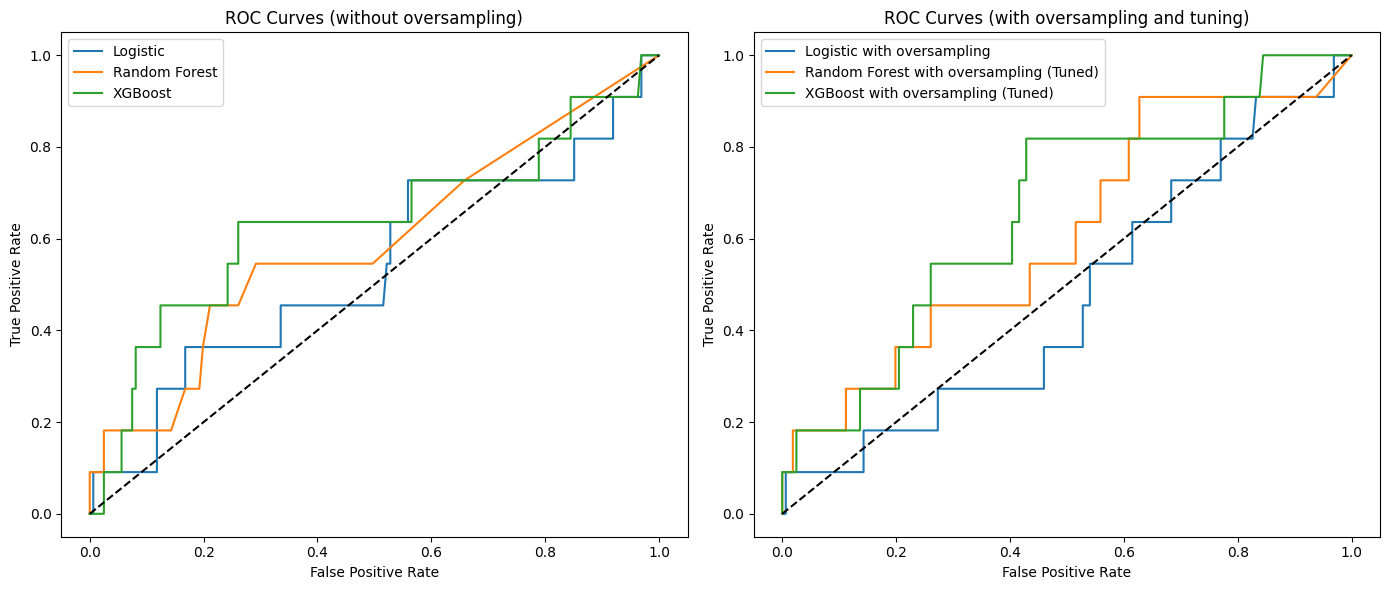

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First plot (without oversampling)
for model, name, X_data in [
    (log_model, "Logistic", X_test_scaled),
    (rf, "Random Forest", X_test_scaled),
    (xgb_model, "XGBoost", X_test_scaled)
]:
    probs = model.predict_proba(X_data)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=name)

axes[0].plot([0,1], [0,1], 'k--')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (without oversampling)")
axes[0].legend()

# Second plot (with oversampling and hyperparameter tuning)
for model, name, X_data in [
    (log_oversampled, "Logistic with oversampling", X_test_scaled),
    (best_rf_model, "Random Forest with oversampling (Tuned)", X_test_scaled),
    (best_xgb_model, "XGBoost with oversampling (Tuned)", X_test_scaled)
]:
    probs = model.predict_proba(X_data)[:,1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[1].plot(fpr, tpr, label=name)

axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves (with oversampling and tuning)")
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_curve_comparison.png') # Save the figure
plt.show()

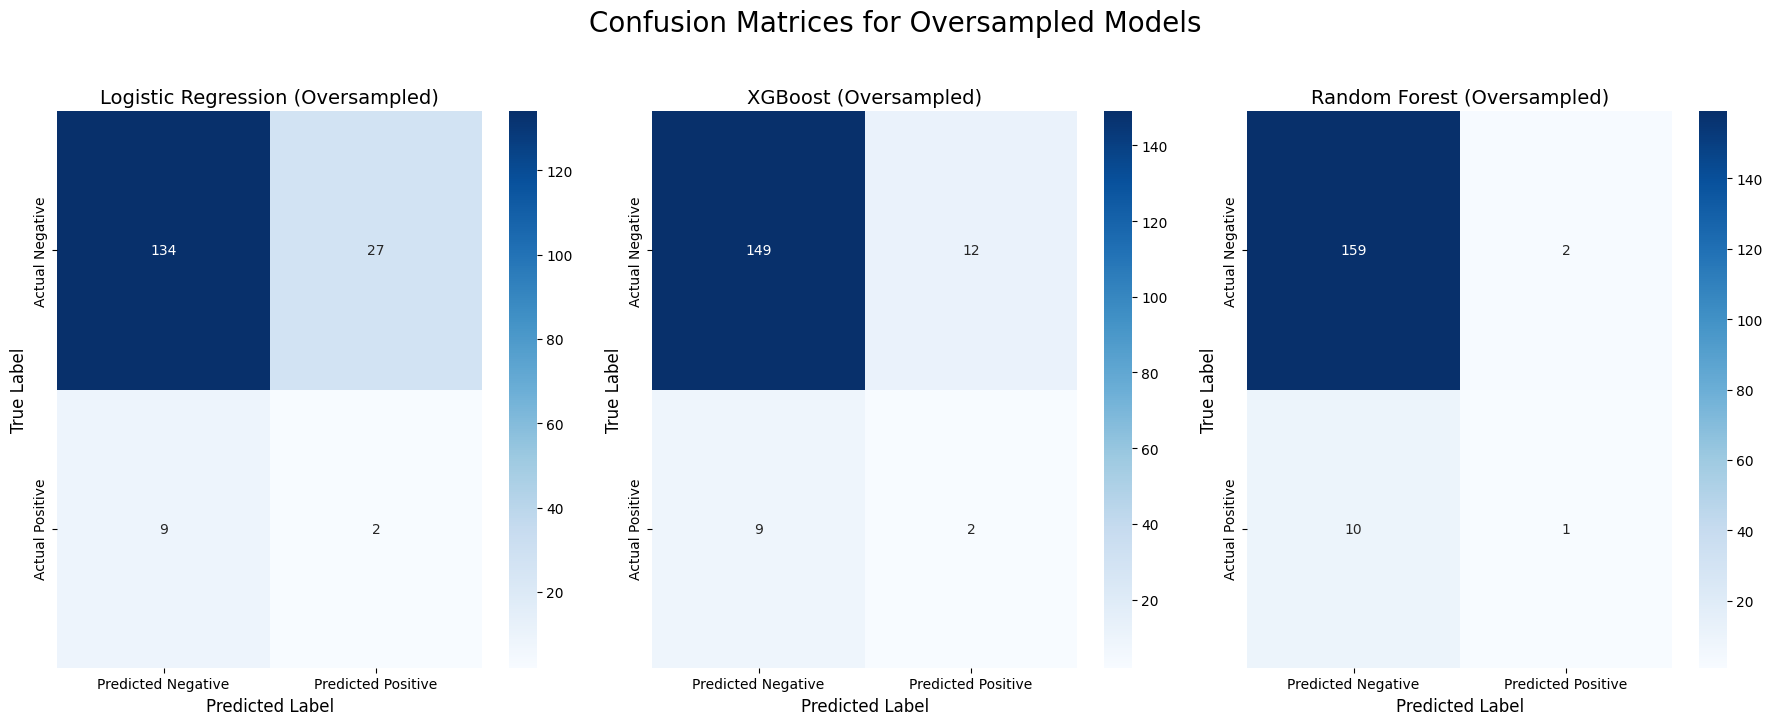

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression (Oversampled)": log_oversampled,
    "XGBoost (Oversampled)": best_xgb_model,
    "Random Forest (Oversampled)": best_rf_model
}

X_test_data = {
    "Logistic Regression (Oversampled)": X_test_scaled,
    "XGBoost (Oversampled)": X_test_scaled,
    "Random Forest (Oversampled)": X_test_scaled
}

fig, axes = plt.subplots(1, 3, figsize=(18, 7)) # Increased figsize for better spacing
axes = axes.flatten()

fig.suptitle('Confusion Matrices for Oversampled Models', fontsize=20, y=1.03) # Main title for the figure

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]
    X_data = X_test_data[name]
    y_pred = model.predict(X_data)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    ax.set_title(f'{name}', fontsize=14) # Increased subplot title font size
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices_oversampled.png', bbox_inches='tight') # Save the figure
plt.show()

## **GBD PREVALANCE AND INCIDENCE OF CERVICAL CANCER IN WEST AFRICAN COUNTRIES**

In [24]:
df_incidence = 'https://github.com/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/edit/main/data/IHME-GBD_2023_DATA-a243a57e.csv'
incidence = pd.read_csv(df_incidence)
#df_prevalence = 'https://raw.githubusercontent.com/opeoluwa22/Lifestyle-Based-Cervical-Cancer-Risk-Prediction-/refs/heads/main/data/IHME-GBD_2023_DATA-ee7a3b09.csv'
#prevalence = pd.read_csv(df_prevalence)

ParserError: Error tokenizing data. C error: Expected 1 fields in line 39, saw 2


In [ ]:
incidence = incidence[['measure_name','location_name','age_name','year','val','upper','lower' ]]
incidence.info()

In [ ]:
prevalence = prevalence[['measure_name','location_name','age_name','year','val','upper','lower' ]]
prevalence.info()

### Regional Trend (Average Across West Africa)

In [ ]:
regional_incidence_trend = (
    incidence.groupby("year")[["val", "upper", "lower"]]
    .mean()
    .reset_index()
)

regional_prevalence_trend = (
    prevalence.groupby("year")[["val", "upper", "lower"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot for Incidence
axes[0].plot(regional_incidence_trend["year"], regional_incidence_trend["val"],
             label="Mean Incidence", color='blue', marker='o', markersize=4)
axes[0].fill_between(regional_incidence_trend["year"], regional_incidence_trend["lower"],
                     regional_incidence_trend["upper"], color='lightblue', alpha=0.4,
                     label="95% Confidence Interval")
axes[0].set_title("Average Cervical Cancer Incidence in West Africa (with Confidence Interval)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Mean Incidence Rate")
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Plot for Prevalence
axes[1].plot(regional_prevalence_trend["year"], regional_prevalence_trend["val"],
             label="Mean Prevalence", color='red', marker='o', markersize=4)
axes[1].fill_between(regional_prevalence_trend["year"], regional_prevalence_trend["lower"],
                     regional_prevalence_trend["upper"], color='lightcoral', alpha=0.4,
                     label="95% Confidence Interval")
axes[1].set_title("Average Cervical Cancer Prevalence in West Africa (with Confidence Interval)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean Prevalence Rate")
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.savefig('regional_incidence_prevalence_trends.png')
plt.show()

In [ ]:
latest_year = incidence["year"].max()

# --- Incidence Data Processing ---
latest_incidence = incidence[
    (incidence["year"] == latest_year) &
    (incidence["age_name"] == "15-49 years")
]
latest_incidence_sorted = latest_incidence.sort_values("val", ascending=False)

incidence_lower_errors = latest_incidence_sorted["val"] - latest_incidence_sorted["lower"]
incidence_upper_errors = latest_incidence_sorted["upper"] - latest_incidence_sorted["val"]

# --- Prevalence Data Processing ---
latest_prevalence = prevalence[
    (prevalence["year"] == latest_year) &
    (prevalence["age_name"] == "15-49 years")
]
latest_prevalence_sorted = latest_prevalence.sort_values("val", ascending=False)

prevalence_lower_errors = latest_prevalence_sorted["val"] - latest_prevalence_sorted["lower"]
prevalence_upper_errors = latest_prevalence_sorted["upper"] - latest_prevalence_sorted["val"]

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot for Incidence
axes[0].bar(
    x=latest_incidence_sorted["location_name"],
    height=latest_incidence_sorted["val"],
    yerr=[incidence_lower_errors, incidence_upper_errors],
    capsize=5,
    color='skyblue'
)
axes[0].set_xticks(range(len(latest_incidence_sorted["location_name"])))
axes[0].set_xticklabels(latest_incidence_sorted["location_name"], rotation=60, ha='right')
axes[0].set_title(
    "Cervical Cancer Incidence Comparison (15-49 years) in West African Countries (Latest Year)",
                  fontsize=14
    )
axes[0].set_xlabel("Country", fontsize=12)
axes[0].set_ylabel("Incidence Rate (per 100,000)", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Prevalence
axes[1].bar(
    x=latest_prevalence_sorted["location_name"],
    height=latest_prevalence_sorted["val"],
    yerr=[prevalence_lower_errors, prevalence_upper_errors],
    capsize=5,
    color='green'
)
axes[1].set_xticks(range(len(latest_prevalence_sorted["location_name"])))
axes[1].set_xticklabels(latest_prevalence_sorted["location_name"], rotation=60, ha='right')
axes[1].set_title(
    "Cervical Cancer Prevalence Comparison (15-49 years) in West African Countries (Latest Year)",
                  fontsize=14
    )
axes[1].set_xlabel("Country", fontsize=12)
axes[1].set_ylabel("Prevalence Rate (per 100,000)", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('country_comparison_incidence_prevalence.png')
plt.show()

### Country comparison (latest year)

### Age group comparison

In [ ]:
latest_year = incidence["year"].max()

# Incidence Data Processing
latest_incidence_age = incidence[
    incidence["year"] == latest_year
]
incidence_age_group_data = latest_incidence_age.groupby("age_name")[["val", "upper", "lower"]]\
.mean().reset_index()

# Prevalence Data Processing
latest_prevalence_age = prevalence[
    prevalence["year"] == latest_year
]
prevalence_age_group_data = latest_prevalence_age.groupby("age_name")[["val", "upper", "lower"]]\
.mean().reset_index()

# Define a specific order for age groups
age_order = ["15-49 years", "50-69 years", "70+ years"]

incidence_age_group_data["age_name"] = pd.Categorical(incidence_age_group_data["age_name"],
                                                      categories=age_order, ordered=True)
incidence_age_group_data = incidence_age_group_data.sort_values("age_name")

prevalence_age_group_data["age_name"] = pd.Categorical(prevalence_age_group_data["age_name"],
                                                       categories=age_order, ordered=True)
prevalence_age_group_data = prevalence_age_group_data.sort_values("age_name")

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Create a figure with 2 subplots

# Plot for Incidence by Age Group
incidence_lower_errors = incidence_age_group_data["val"] - incidence_age_group_data["lower"]
incidence_upper_errors = incidence_age_group_data["upper"] - incidence_age_group_data["val"]

axes[0].bar(
    x=incidence_age_group_data["age_name"],
    height=incidence_age_group_data["val"],
    yerr=[incidence_lower_errors, incidence_upper_errors],
    capsize=5,
    color=['skyblue', 'lightcoral', 'lightgreen']
)
axes[0].set_title("Average Cervical Cancer Incidence by Age Group (Latest Year)", fontsize=14)
axes[0].set_xlabel("Age Group", fontsize=12)
axes[0].set_ylabel("Average Incidence Rate (per 100,000)", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Prevalence by Age Group
prevalence_lower_errors = prevalence_age_group_data["val"] - prevalence_age_group_data["lower"]
prevalence_upper_errors = prevalence_age_group_data["upper"] - prevalence_age_group_data["val"]

axes[1].bar(
    x=prevalence_age_group_data["age_name"],
    height=prevalence_age_group_data["val"],
    yerr=[prevalence_lower_errors, prevalence_upper_errors],
    capsize=5,
    color=['orchid', 'mediumseagreen', 'gold'] # Different colors for prevalence
)
axes[1].set_title("Average Cervical Cancer Prevalence by Age Group (Latest Year)", fontsize=14)
axes[1].set_xlabel("Age Group", fontsize=12)
axes[1].set_ylabel("Average Prevalence Rate (per 100,000)", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()